# Preprocessing - life_style_data.duckdb

## 1. Importation des librairies essentielles

In [365]:
from pathlib import Path
import joblib, json, yaml
from datetime import datetime

import duckdb
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform

import shap
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Variables globales

In [366]:
# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# Configuration traitements
search_best_features = False
search_best_params = False
# augmente si tu veux explorer plus
N_ITER = 100

# Chemins complets
db_path = project_root / "src" / "data" / "raw" / "life_style_data" / "life_style_data"
export_dir = project_root / "src" / "data" / "processed" / "life_style_data"
model_dir = project_root / "src" / "models" / "v1" / "life_style_data"


# Configuration feature selection
config_path = Path(project_root / "src/config/features.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
# selected_features = config["selected_features_full_columns"]
selected_features = config["selected_features_test"]
optional_features = config["optional_features"]

# Configuration feature selection
config_path = Path(project_root / "src/config/features_processed.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    config_processed = yaml.safe_load(f)
# features_processed = config_processed["features_processed_full_columns"]
features_processed = config_processed["features_processed_test"]

#Configuration du modèle final
config_path = Path(project_root / "src/config/inference.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    config_inference = yaml.safe_load(f)
inference = config_inference["inference_full_columns"]
# inference = config["inference_test"]

MODEL_VERSION = "v3.1-minimal"

## 3. Éviter de réutiliser d’anciens artefacts

In [367]:
for p in ["model.joblib","feature_scaler.joblib","target_scaler.joblib"]:
    f = (model_dir / p)
    if f.exists():
        f.unlink()

## 4. Nettoyage des données

### 4.1. Contexte & objectifs

Ce chapitre prépare le dataset life_style_data pour la modélisation.
Objectifs :
- Corriger les types (notamment les décimales avec virgules) ;
- Quantifier et traiter les valeurs manquantes ;
- Détecter/supprimer les doublons ;
- Poser des règles de plausibilité métier (sans censurer) ;
- Produire un rapport de nettoyage et des artefacts (dataset nettoyé).

Entrée : table DuckDB life_style_data (chargée via DBeaver).
Sorties : df_clean (Parquet/CSV), tableaux de suivi (manquants, conversions, doublons, flags).

### 4.2. Imports, paramètres, chargement depuis DuckDB

In [368]:
# Connexion à la base DuckDB
con = duckdb.connect(str(db_path))
# Connexion SQLite
con_sqlite = sqlite3.connect(export_dir / "life_style_data_val.db")

# Chargement de la table
df = con.execute("SELECT * FROM life_style_data").fetchdf()

# Extraire les 10 premières lignes
df_sample = df.head(10).copy()
df = df.iloc[10:].reset_index(drop=True)

# Écriture du sample dans la base SQLite
table_name = "sample"
df_sample.to_sql(table_name, con_sqlite, if_exists="replace", index=False)

print(f"✔ Échantillon extrait : {df_sample.shape[0]} lignes")
print(f"✔ Données restantes  : {df.shape[0]} lignes")

# Vérification du chargement
shape_before = df.shape
print(f"✔ Données chargées : {shape_before[0]} lignes, {shape_before[1]} colonnes")
display(df.head(3))

✔ Échantillon extrait : 10 lignes
✔ Données restantes  : 19990 lignes
✔ Données chargées : 19990 lignes, 54 colonnes


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,50.51,Male,86.37,1.63,160.92,143.20,57.87,1.69,1974.26,Strength,...,2065.28,0.501588,1.189302,0.828045,0.889883,501.74,61.260921,1203.9560,9.983135e+19,High
1,47.77,Female,83.89,1.82,176.36,148.74,69.91,1.91,2733.40,HIIT,...,1848.79,0.500133,1.111813,0.740535,0.843389,-501.40,64.050587,1379.5166,1.116947e+20,Very High
2,19.00,Male,82.66,1.96,173.75,168.71,62.16,1.89,2700.62,HIIT,...,1446.67,0.502727,0.866199,0.954835,0.970993,-131.62,62.715145,1353.0888,1.039329e+20,High


### 4.3. Audit qualité initial

On dresse un état des lieux :
- Répartition des types et cardinalités ;
- Valeurs manquantes (%) par colonne ;
- Doublons potentiels.

Cet instantané nous sert de référence avant toute modification.

In [369]:
# Audit qualité initial
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
dup_count = df.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing_%": df.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"• Doublons détectés (avant): {dup_count}")
display(missing_pct.to_frame("missing_%").head(20))
display(summary_types.head(20))

• Doublons détectés (avant): 0


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


,dtype,n_unique,missing_%
Age,float64,3950,0.0
Body Part,object,7,0.0
prep_time_min,float64,5384,0.0
cook_time_min,float64,9405,0.0
rating,float64,414,0.0
Name of Exercise,object,55,0.0
Sets,float64,30,0.0
Reps,float64,654,0.0
Benefit,object,49,0.0
Burns Calories (per 30 min),float64,5765,0.0


### 4.4. Correction de types (décimales à virgule, espaces insécables)

Dans de nombreux exports, les colonnes numériques arrivent en texte (object) avec :
- des virgules à la place du point décimal ;
- des espaces insécables (\u00A0) ou espaces.

On corrige proprement pour garantir la cohérence numérique.

In [370]:
# Conversion robuste des colonnes numériques candidates (si présentes)
num_candidates = [
    "Age","Weight (kg)","Height (m)","Max_BPM","Avg_BPM","Resting_BPM",
    "Session_Duration (hours)","Fat_Percentage","Water_Intake (liters)",
    "Workout_Frequency (days/week)","BMI","Carbs","Proteins","Fats","Calories",
    "sugar_g","sodium_mg","cholesterol_mg","serving_size_g","prep_time_min","cook_time_min",
    "rating","BMI_calc","cal_from_macros","pct_carbs","protein_per_kg","pct_HRR","pct_maxHR",
    "cal_balance","lean_mass_kg","expected_burn","Burns Calories (per 30 min)","Calories_Burned"
]

convert_log = []
df_conv = df.copy()

for c in [col for col in num_candidates if col in df_conv.columns]:
    if df_conv[c].dtype == "object":
        before_na = df_conv[c].isna().sum()
        df_conv[c] = (df_conv[c]
            .astype(str)
            .str.replace(",", ".", regex=False)     # virgule ⇒ point
            .str.replace("\u00A0", "", regex=False) # espace insécable
            .str.strip()
        )
        df_conv[c] = pd.to_numeric(df_conv[c], errors="coerce")
        after_na = df_conv[c].isna().sum()
        convert_log.append({"column": c, "was_object": True, "na_before": before_na, "na_after": after_na})

convert_report = pd.DataFrame(convert_log).sort_values("column") if convert_log else pd.DataFrame(columns=["column","was_object","na_before","na_after"])
display(convert_report)

,column,was_object,na_before,na_after


### 4.5. Règles de plausibilité (flags non bloquants)

On applique des bornes métier pour repérer des valeurs possiblement aberrantes.
On ne supprime pas : on flague pour informer la modélisation et documenter les décisions.

Exemples (paramétrables) :
- Age ∈ [10, 90]
- Max_BPM ∈ [80, 230]
- Session_Duration (hours) ∈ [0.1, 6]
- BMI ∈ [10, 60]

In [371]:
# Flags de plausibilité (ne supprime rien)
df_flag = df_conv.copy()

def safe_between(s, low, high):
    return s.between(low, high) if s.notna().any() else pd.Series(False, index=s.index)

flags = {}
if "Age" in df_flag:               flags["Age_out"] = ~safe_between(df_flag["Age"], 10, 90)
if "Max_BPM" in df_flag:           flags["BPM_out"] = ~safe_between(df_flag["Max_BPM"], 80, 230)
if "Session_Duration (hours)" in df_flag: flags["SessDur_out"] = ~safe_between(df_flag["Session_Duration (hours)"], 0.1, 6)
if "BMI" in df_flag:               flags["BMI_out"] = ~safe_between(df_flag["BMI"], 10, 60)

flag_counts = {k: v.fillna(False).sum() for k, v in flags.items()}
flag_table = pd.DataFrame.from_dict(flag_counts, orient="index", columns=["nb_outliers"]).sort_index()
display(flag_table)

,nb_outliers
Age_out,0
BMI_out,0
BPM_out,0
SessDur_out,0


### 4.6. Imputation des valeurs manquantes (baseline)

Stratégie simple et robuste (baseline reproductible) :
- Numériques → médiane (moins sensible aux outliers) ;
- Catégorielles → mode (valeur la plus fréquente, sinon “Unknown”).

Cette baseline est suffisante pour itérer ; on pourra spécialiser par la suite.

In [372]:
# Imputation des manquants
df_imp = df_flag.copy()

num_cols = df_imp.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_imp.columns if c not in num_cols]

# Numériques → médiane
for c in num_cols:
    if df_imp[c].isna().any():
        df_imp[c] = df_imp[c].fillna(df_imp[c].median())

# Catégorielles → mode (ou "Unknown")
for c in cat_cols:
    if df_imp[c].isna().any():
        m = df_imp[c].mode(dropna=True)
        df_imp[c] = df_imp[c].fillna(m.iloc[0] if not m.empty else "Unknown")

missing_before = missing_pct  # gardé depuis 1.2
missing_after = df_imp.isna().mean().sort_values(ascending=False) * 100

print("✔ Imputation effectuée.")
display(pd.DataFrame({"missing_before_%": missing_before}).head(10))
display(pd.DataFrame({"missing_after_%": missing_after}).head(10))

✔ Imputation effectuée.


,missing_before_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


,missing_after_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


### 4.7. Doublons & incohérences simples

On élimine les doublons stricts (lignes identiques).

Cette opération stabilise la taille du corpus et évite des biais à l’entraînement.

In [373]:
# Doublons
rows_before = df_imp.shape[0]
dup_total = df_imp.duplicated().sum()
df_clean = df_imp.drop_duplicates().reset_index(drop=True)
rows_after = df_clean.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_clean.shape[1]]
})
display(clean_report)

,rows_before,rows_after,duplicates_removed,cols
0,19990,19990,0,54


### 4.8. Rapport de nettoyage

Nous consolidons les éléments clés pour traçabilité et communication :
- Colonnes converties object → numeric ;
- Avant/Après des valeurs manquantes ;
- Nombre de doublons supprimés ;
- Flags de plausibilité relevés.

Ce rapport sert de référence pour justifier les choix et préparer la suite (encodage, scaling).

In [374]:
# Rapport consolidé
sections = {
    "convert_report": convert_report,
    "missing_before_% (top 20)": missing_before.to_frame("missing_%").head(20),
    "missing_after_% (top 20)": missing_after.to_frame("missing_%").head(20),
    "plausibility_flags": flag_table,
    "clean_report": clean_report
}

for title, df_sec in sections.items():
    print("\n" + "="*30 + f" {title} " + "="*30)
    display(df_sec)


============================== convert_report ==============================


,column,was_object,na_before,na_after



============================== missing_before_% (top 20) ==============================


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0



============================== missing_after_% (top 20) ==============================


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0



============================== plausibility_flags ==============================


,nb_outliers
Age_out,0
BMI_out,0
BPM_out,0
SessDur_out,0



============================== clean_report ==============================


,rows_before,rows_after,duplicates_removed,cols
0,19990,19990,0,54


### 4.9. Export des artefacts (dataset nettoyé)

On persiste le dataset nettoyé pour les étapes suivantes (encodage, scaling, split) et pour reproductibilité :
- life_style_data_clean.parquet (format recommandé) ;
- Optionnel : life_style_data_clean.csv.

In [375]:
# Export artefacts
parquet_path = export_dir / "life_style_data_clean.parquet"

df_clean.to_parquet(parquet_path, index=False, engine="fastparquet")

print(f"✔ Export parquet : {parquet_path}")
print(f"✔ Shape final    : {df_clean.shape}")

✔ Export parquet : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_clean.parquet
✔ Shape final    : (19990, 54)


### 4.9. Définition des champs métier pour l'entrainement

In [376]:
# Charger les artefacts nettoyés
df_features = pd.read_parquet(parquet_path)

print(f"✔ Dataset chargé : {df_features.shape[0]} lignes, {df_features.shape[1]} colonnes")
print(df_features.head(3))


# Vérifier quelles colonnes sont présentes dans le DataFrame
print(df_features.columns)
existing_features = [col for col in selected_features if col in df_features.columns]
missing_features = [col for col in selected_features if col not in df_features.columns]

# Filtrage du DataFrame sur les colonnes existantes
df_features = df_features[existing_features]

print(f"Colonnes conservées : {len(existing_features)}")
if missing_features:
    print(f"/!\ Colonnes absentes du dataset : {missing_features}")


parquet_path = export_dir / "life_style_data_feature.parquet"
df_features.to_parquet(parquet_path, index=False, engine="fastparquet")

print(f"Export parquet : {parquet_path}")
print(f"Shape final    : {df_clean.shape}")

✔ Dataset chargé : 19990 lignes, 54 colonnes
     Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0  50.51    Male        86.37        1.63   160.92   143.20        57.87   
1  47.77  Female        83.89        1.82   176.36   148.74        69.91   
2  19.00    Male        82.66        1.96   173.75   168.71        62.16   

   Session_Duration (hours)  Calories_Burned Workout_Type  ...  \
0                      1.69          1974.26     Strength  ...   
1                      1.91          2733.40         HIIT  ...   
2                      1.89          2700.62         HIIT  ...   

   cal_from_macros  pct_carbs  protein_per_kg   pct_HRR  pct_maxHR  \
0          2065.28   0.501588        1.189302  0.828045   0.889883   
1          1848.79   0.500133        1.111813  0.740535   0.843389   
2          1446.67   0.502727        0.866199  0.954835   0.970993   

   cal_balance  lean_mass_kg  expected_burn  Burns Calories (per 30 min)_bc  \
0       501.74     61.260

### 4.10. Critères d’acceptation & décisions

- Types numériques/catégoriels conformes au dictionnaire ;
- Manquants résiduels documentés et ≤ seuils tolérés (par défaut, 5%) ;
- Doublons supprimés (ou chiffrés et justifiés si conservés) ;
- Flags de plausibilité suivis (pas de censure sans décision métier explicite).

Décisions à garder au journal :
- Colonnes converties, colonnes fortement manquantes et stratégie appliquée ;
- Seuils de plausibilité retenus et impact (aucune ligne supprimée à ce stade) ;
- Lieux d’export des artefacts.

## 5. Encodage des variables catégorielles

### 5.1. Objectifs

Cette étape consiste à transformer les variables catégorielles du jeu de données nettoyé en représentations numériques exploitables par les algorithmes de Machine Learning.
L’encodage rend les colonnes qualitatives compatibles avec les modèles tout en préservant l’information sémantique.
Deux approches principales sont appliquées selon la nature des catégories :
- Encodage ordinal pour les variables hiérarchiques (ex. niveau d’expérience) ;
- Encodage one-hot pour les variables nominales (ex. type d’exercice, partie du corps, équipement).

### 5.2. Chargement du dataset nettoyé

In [377]:
# Charger les artefacts nettoyés
df_clean = pd.read_parquet(parquet_path)

print(f"✔ Dataset chargé : {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes")
df_clean.head(3)

✔ Dataset chargé : 19990 lignes, 19 colonnes


,Calories_Burned,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Experience_Level,Workout_Type,Difficulty Level,Body Part,Equipment Needed,Workout_Frequency (days/week),Water_Intake (liters),Fat_Percentage,diet_type,meal_type
0,1974.26,50.51,Male,86.37,1.63,160.92,143.20,57.87,1.69,2.98,Strength,Intermediate,Abs,Wall,4.01,3.49,29.071528,Keto,Breakfast
1,2733.40,47.77,Female,83.89,1.82,176.36,148.74,69.91,1.91,3.01,HIIT,Advanced,Shoulders,Dumbbells,5.02,3.51,23.649318,Keto,Snack
2,2700.62,19.00,Male,82.66,1.96,173.75,168.71,62.16,1.89,2.99,HIIT,Advanced,Abs,Bench or Sturdy Surface,5.02,3.50,24.128787,Vegan,Dinner


### 5.3. Identification des variables catégorielles
On repère les variables non numériques à encoder.
L’objectif est de distinguer :
- les variables nominales (non ordonnées),
- les variables ordinales (possédant une hiérarchie logique).

In [378]:
# Identification des colonnes catégorielles
cat_cols = df_clean.select_dtypes(exclude=["number"]).columns.tolist()
print(f"🔎 {len(cat_cols)} variables catégorielles détectées :")
cat_cols

🔎 7 variables catégorielles détectées :


['Gender',
 'Workout_Type',
 'Difficulty Level',
 'Body Part',
 'Equipment Needed',
 'diet_type',
 'meal_type']

### 5.4. Encodage ordinal

Les variables catégorielles ordonnées (par ex. Experience_Level, Difficulty Level) sont converties en valeurs entières selon leur progression logique.

Cette méthode conserve la hiérarchie implicite entre les modalités.

In [379]:
# Encodage ordinal sur la variable à hiérarchie logique : Difficulty Level
difficulty_map = {
    "Beginner": 0,
    "Intermediate": 1,
    "Advanced": 2,
}

if "Difficulty Level" in df_clean.columns:
    df_clean["Difficulty Level"] = (
        df_clean["Difficulty Level"]
        .map(difficulty_map)
        .astype(float)
    )
    print("Encodage ordinal appliqué sur 'Difficulty Level' :", difficulty_map)


gender_encoder = OrdinalEncoder()
df_clean[["Gender"]] = gender_encoder.fit_transform(df_features[["Gender"]])

Encodage ordinal appliqué sur 'Difficulty Level' : {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}


### 5.5. Encodage One-Hot

Les variables nominales (sans hiérarchie) sont transformées par One-Hot Encoding, créant une colonne binaire par modalité.

Cela permet d’éviter toute interprétation de relation d’ordre entre catégories.

In [380]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=[col for col in cat_cols if col not in ["Experience_Level", "Difficulty Level"]],
    drop_first=True
)

print(f"One-Hot Encoding appliqué : {df_encoded.shape[1]} colonnes au total")
df_encoded.head(10)

One-Hot Encoding appliqué : 50 colonnes au total


,Calories_Burned,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Experience_Level,Difficulty Level,...,Equipment Needed_Step or Box,Equipment Needed_Wall,diet_type_Keto,diet_type_Low-Carb,diet_type_Paleo,diet_type_Vegan,diet_type_Vegetarian,meal_type_Dinner,meal_type_Lunch,meal_type_Snack
0,1974.26,50.51,86.37,1.63,160.92,143.20,57.87,1.69,2.98,1.0,...,False,True,True,False,False,False,False,False,False,False
1,2733.40,47.77,83.89,1.82,176.36,148.74,69.91,1.91,3.01,2.0,...,False,False,True,False,False,False,False,False,False,True
2,2700.62,19.00,82.66,1.96,173.75,168.71,62.16,1.89,2.99,2.0,...,False,False,False,False,False,True,False,True,False,False
3,2345.20,38.01,57.67,1.56,184.91,132.43,54.04,1.64,3.00,2.0,...,False,False,False,True,False,False,False,False,False,False
4,743.85,27.39,71.79,1.97,180.96,151.11,72.68,0.75,1.02,2.0,...,False,False,False,True,False,False,False,False,True,False
5,1293.84,18.86,95.12,1.85,189.48,142.51,49.90,1.20,1.98,2.0,...,False,False,False,False,True,False,False,False,False,True
6,2189.58,40.36,56.88,1.71,168.02,142.67,60.89,1.87,3.01,2.0,...,False,False,False,False,True,False,False,False,False,False
7,1305.60,37.14,76.48,1.77,180.29,127.80,56.76,1.36,2.00,0.0,...,False,False,False,True,False,False,False,False,False,False
8,803.36,18.93,72.56,1.79,177.48,124.41,60.95,0.81,1.02,0.0,...,False,False,False,False,False,False,True,False,True,False
9,1544.40,46.00,60.05,1.68,164.91,147.10,62.34,1.17,2.00,1.0,...,False,True,False,False,False,False,True,False,True,False


### 5.6. Vérification post-encodage

Après encodage :
- Toutes les variables sont numériques ;
- Le nombre de colonnes augmente (selon le nombre de modalités) ;
- Aucun NaN ne doit être réintroduit.

In [381]:
print(f"Forme finale du dataset encodé : {df_encoded.shape}")
print(f"Valeurs manquantes totales : {df_encoded.isna().sum().sum()}")

# Aperçu d'un sous-ensemble des nouvelles colonnes encodées
df_encoded.filter(like="Workout_Type").head(10)

Forme finale du dataset encodé : (19990, 50)
Valeurs manquantes totales : 0


,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,False,True,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False
5,False,True,False
6,False,True,False
7,False,False,False
8,False,True,False
9,True,False,False


### 5.7. Export du dataset encodé

On exporte le jeu de données final encodé pour les étapes suivantes :
- Mise à l’échelle / normalisation
- Split train/test

In [382]:
encoded_path = export_dir / "life_style_data_encoded.parquet"
df_encoded.to_parquet(encoded_path, index=False)
print(f"Export du dataset encodé : {encoded_path}")

Export du dataset encodé : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_encoded.parquet



L’encodage garantit la compatibilité du jeu de données avec les algorithmes de Machine Learning.

Les variables catégorielles hiérarchiques ont été traitées par encodage ordinal, et les variables nominales par encodage one-hot, réduisant les risques de biais d’interprétation.

## 6. Mise à l’échelle / Normalisation des variables numériques

### 6.1. Objectifs

Cette étape vise à homogénéiser les échelles des variables numériques afin d’éviter qu’une variable à grande amplitude (ex. Calories ou Weight (kg)) ne domine les autres lors de l’apprentissage du modèle.
Deux techniques sont généralement utilisées :
- StandardScaler : recentre les données autour de 0 et réduit leur variance à 1 ;
- MinMaxScaler : ramène les valeurs dans un intervalle [0,1].

Le choix du scaler dépend de la nature des modèles :
- Les algorithmes linéaires ou ceux utilisant une distance (SVM, KNN, PCA) sont sensibles à l’échelle → StandardScaler privilégié ;
- Les modèles arborescents (Random Forest, XGBoost) y sont peu sensibles.

In [383]:
encoded_path = export_dir / "life_style_data_encoded.parquet"

df_encoded = pd.read_parquet(encoded_path)
print(f"Dataset encodé chargé : {df_encoded.shape[0]} lignes, {df_encoded.shape[1]} colonnes")
df_encoded.head(3)

Dataset encodé chargé : 19990 lignes, 50 colonnes


,Calories_Burned,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Experience_Level,Difficulty Level,...,Equipment Needed_Step or Box,Equipment Needed_Wall,diet_type_Keto,diet_type_Low-Carb,diet_type_Paleo,diet_type_Vegan,diet_type_Vegetarian,meal_type_Dinner,meal_type_Lunch,meal_type_Snack
0,1974.26,50.51,86.37,1.63,160.92,143.20,57.87,1.69,2.98,1.0,...,False,True,True,False,False,False,False,False,False,False
1,2733.40,47.77,83.89,1.82,176.36,148.74,69.91,1.91,3.01,2.0,...,False,False,True,False,False,False,False,False,False,True
2,2700.62,19.00,82.66,1.96,173.75,168.71,62.16,1.89,2.99,2.0,...,False,False,False,False,False,True,False,True,False,False


### 6.2. Sélection des variables numériques

On identifie toutes les variables numériques du dataset afin d’appliquer la mise à l’échelle uniquement sur celles qui ne sont pas déjà binaires (0/1).

Les colonnes issues du One-Hot Encoding ne doivent pas être modifiées.

In [384]:
# Identifier toutes les colonnes numériques
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Exclure les colonnes binaires (issues du One-Hot Encoding)
non_binary_num_cols = [col for col in num_cols if df_encoded[col].nunique() > 2]

print(f"Variables numériques à mettre à l’échelle : {len(non_binary_num_cols)}")
non_binary_num_cols[:15]  # aperçu

Variables numériques à mettre à l’échelle : 13


['Calories_Burned',
 'Age',
 'Weight (kg)',
 'Height (m)',
 'Max_BPM',
 'Avg_BPM',
 'Resting_BPM',
 'Session_Duration (hours)',
 'Experience_Level',
 'Difficulty Level',
 'Workout_Frequency (days/week)',
 'Water_Intake (liters)',
 'Fat_Percentage']

### 6.3. Application du StandardScaler

Le StandardScaler est appliqué sur toutes les variables continues identifiées.

Cette normalisation rend la moyenne nulle et la variance unitaire, garantissant un traitement équilibré par les algorithmes sensibles à l’échelle des features.

In [385]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_encoded[non_binary_num_cols])

# Remplacer les colonnes originales par leurs versions normalisées
df_scaled = df_encoded.copy()
df_scaled[non_binary_num_cols] = scaled_values

print("Standardisation terminée.")
df_scaled[non_binary_num_cols].describe().T.head(10)

Standardisation terminée.


,count,mean,std,min,25%,50%,75%,max
Calories_Burned,19990.0,-1.094783e-16,1.000025,-1.905592,-0.735383,-0.096486,0.543406,3.207234
Age,19990.0,1.206750e-16,1.000025,-1.721249,-0.881770,0.084003,0.889639,1.718387
Weight (kg),19990.0,1.597744e-16,1.000025,-1.639784,-0.743384,-0.184197,0.576066,2.685888
Height (m),19990.0,1.135304e-15,1.000025,-1.834886,-0.811578,-0.103134,0.605310,2.258346
Max_BPM,19990.0,4.130318e-16,1.000025,-1.787597,-0.854658,0.021819,0.829238,1.715705
Avg_BPM,19990.0,-2.847147e-16,1.000025,-1.726579,-0.875041,-0.050136,0.865880,1.831657
Resting_BPM,19990.0,9.568690e-16,1.000025,-1.743387,-0.855687,0.000457,0.808580,1.688048
Session_Duration (hours),19990.0,2.317528e-16,1.000025,-2.254353,-0.613733,0.030796,0.587435,2.228054
Experience_Level,19990.0,3.284350e-16,1.000025,-1.099061,-1.085478,0.245683,0.286433,1.685511
Difficulty Level,19990.0,-2.985772e-17,1.000025,-1.226555,-1.226555,-0.000491,1.225574,1.225574


### 6.4. Vérification post-normalisation

Après mise à l’échelle :
- La moyenne des colonnes est proche de 0 ;
- L’écart-type est proche de 1 ;
- Les colonnes binaires n’ont pas été modifiées.

In [386]:
# Vérification moyenne ~0 et std ~1
check_stats = df_scaled[non_binary_num_cols].agg(["mean", "std"]).T
check_stats.head(10)

,mean,std
Calories_Burned,-1.094783e-16,1.000025
Age,1.206750e-16,1.000025
Weight (kg),1.597744e-16,1.000025
Height (m),1.135304e-15,1.000025
Max_BPM,4.130318e-16,1.000025
Avg_BPM,-2.847147e-16,1.000025
Resting_BPM,9.568690e-16,1.000025
Session_Duration (hours),2.317528e-16,1.000025
Experience_Level,3.284350e-16,1.000025
Difficulty Level,-2.985772e-17,1.000025


### 6.5. Export du dataset normalisé

Le dataset final normalisé est sauvegardé pour la suite du pipeline :
- life_style_data_scaled.parquet : pour la modélisation supervisée ;
- life_style_data_scaled.csv : pour inspection rapide sous DBeaver.

In [387]:
scaled_path = export_dir / "life_style_data_scaled.parquet"
df_scaled.to_parquet(scaled_path, index=False)

print(f"Export parquet : {scaled_path}")
print(f"Shape final    : {df_scaled.shape}")

Export parquet : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_scaled.parquet
Shape final    : (19990, 50)


Critères de validation :
- Moyenne ≈ 0 et écart-type ≈ 1 pour les colonnes normalisées ;
- Aucune valeur manquante ou anormale après transformation ;
- Colonnes binaires conservées inchangées ;
- Fichiers d’export générés sans perte de structure.

Cette étape garantit une échelle cohérente entre toutes les variables continues, assurant un apprentissage plus stable et une meilleure convergence lors de la modélisation.

## 7. Séparation features/target et split en jeux d’entraînement et de test

### 7.1. Objectif

L’objectif de cette étape est de préparer les données d’apprentissage en distinguant :
- les features (X) : variables explicatives,
- la target (y) : variable cible à prédire.

Le jeu de données est ensuite découpé en deux sous-ensembles :
- Jeu d’entraînement (train set) : pour ajuster les paramètres du modèle (généralement 80 %) ;
- Jeu de test (test set) : pour évaluer sa capacité de généralisation (généralement 20 %).

Cette séparation est une pratique fondamentale du Machine Learning supervisé, garantissant la fiabilité de l’évaluation des performances.

In [388]:
scaled_path = export_dir / "life_style_data_scaled.parquet"

df_scaled = pd.read_parquet(scaled_path)

print(f"Dataset normalisé chargé : {df_scaled.shape[0]} lignes, {df_scaled.shape[1]} colonnes")
df_scaled.head(3)

Dataset normalisé chargé : 19990 lignes, 50 colonnes


,Calories_Burned,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Experience_Level,Difficulty Level,...,Equipment Needed_Step or Box,Equipment Needed_Wall,diet_type_Keto,diet_type_Low-Carb,diet_type_Paleo,diet_type_Vegan,diet_type_Vegetarian,meal_type_Dinner,meal_type_Lunch,meal_type_Snack
0,1.382179,0.962278,0.588936,-0.732862,-1.647743,-0.035418,-0.593630,1.261261,1.590428,-0.000491,...,False,True,True,False,False,False,False,False,False,False
1,2.893779,0.736106,0.471809,0.762742,-0.306534,0.352855,1.058288,1.905790,1.631178,1.225574,...,False,False,True,False,False,False,False,False,False,True
2,2.828508,-1.638705,0.413717,1.864766,-0.533254,1.752461,-0.005031,1.847196,1.604011,1.225574,...,False,False,False,False,False,True,False,True,False,False


### 7.2. Définition de la variable cible

La variable à prédire dans ce projet est Calories_Burned (y_calories_burned dans la table).

Elle représente la dépense calorique totale estimée selon les caractéristiques physiques et comportementales de l’utilisateur.

Toutes les autres colonnes servent de features (X).

In [389]:
# Identifier la colonne cible
target_col = "Calories_Burned"

# Vérification que la variable existe bien
assert target_col in df_scaled.columns, f"La colonne cible {target_col} est introuvable."

# Séparation X (features) / y (target)
X = df_scaled.drop(columns=[target_col])
print(X)
y = df_scaled[target_col]
print(y)

print(f"Features (X) : {X.shape[1]} colonnes")
print(f"Target (y)   : {y.name}")

            Age  Weight (kg)  Height (m)   Max_BPM   Avg_BPM  Resting_BPM  \
0      0.962278     0.588936   -0.732862 -1.647743 -0.035418    -0.593630   
1      0.736106     0.471809    0.762742 -0.306534  0.352855     1.058288   
2     -1.638705     0.413717    1.864766 -0.533254  1.752461    -0.005031   
3     -0.069530    -0.766527   -1.283874  0.436170 -0.790238    -1.119116   
4     -0.946155    -0.099658    1.943482  0.093050  0.518958     1.438340   
...         ...          ...         ...       ...       ...          ...   
19985  0.653561     1.152846    1.392470  1.677484  0.313607     0.209005   
19986  0.126100     0.671586    1.156322  1.415149 -0.667589    -1.119116   
19987  0.945769    -1.308239   -0.417998 -1.437528  0.996239    -0.075004   
19988  1.114986    -1.397974   -0.811578 -0.053754 -1.575195    -0.180650   
19989 -0.767033    -0.721187   -0.890294  1.579325 -1.539451     1.351902   

       Session_Duration (hours)  Experience_Level  Difficulty Level  \
0   

### 7.3. Split train/test/val

Le split est effectué avec un ratio suivant :
- Train (70 %) → apprentissage des poids du modèle
- Validation (15 %) → sélection des hyperparamètres et early stopping
- Test (15 %) → évaluation finale, non touché avant la fin du projet

In [390]:
# --- Charger les features BRUTES après encodage, avant scaling global ---
raw_feat_path = export_dir / "life_style_data_encoded.parquet"  # dataset encodé, non normalisé
df_feat_raw = pd.read_parquet(raw_feat_path)
print(df_feat_raw.columns)


assert "Calories_Burned" in df_feat_raw.columns
assert set(features_processed) <= set(df_feat_raw.columns), \
    f"Colonnes manquantes dans df_feat_raw : {set(features_processed) - set(df_feat_raw.columns)}"

# X/y bruts (unités réelles pour Age / Weight / Calories_Burned, binaire pour Gender_1.0)
X_raw = df_feat_raw[features_processed].copy()
y_raw = df_feat_raw["Calories_Burned"].copy()

print(f"X_raw shape: {X_raw.shape} | y_raw shape: {y_raw.shape}")

# --- Split BRUT (puisqu'on va fitter les scalers sur TRAIN uniquement) ---
X_temp_raw, X_test_raw, y_temp_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=42
)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_temp_raw, y_temp_raw, test_size=0.1765, random_state=42
)

print(f"Train: {X_train_raw.shape} | Val: {X_val_raw.shape} | Test: {X_test_raw.shape}")
print(f"y_train_raw min/max: {y_train_raw.min():.2f} / {y_train_raw.max():.2f}")

Index(['Calories_Burned', 'Age', 'Weight (kg)', 'Height (m)', 'Max_BPM',
       'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
       'Experience_Level', 'Difficulty Level', 'Workout_Frequency (days/week)',
       'Water_Intake (liters)', 'Fat_Percentage', 'Gender_1.0',
       'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga',
       'Body Part_Arms', 'Body Part_Back', 'Body Part_Chest',
       'Body Part_Forearms', 'Body Part_Legs', 'Body Part_Shoulders',
       'Equipment Needed_Bench or Chair', 'Equipment Needed_Bench or Step',
       'Equipment Needed_Bench or Sturdy Surface',
       'Equipment Needed_Bench, Barbell', 'Equipment Needed_Box or Platform',
       'Equipment Needed_Cable Machine',
       'Equipment Needed_Cable Machine or Resistance Band',
       'Equipment Needed_Dumbbells', 'Equipment Needed_Dumbbells or Barbell',
       'Equipment Needed_Kettlebell', 'Equipment Needed_Low Bar or TRX',
       'Equipment Needed_None or Dumbbell',
       'Equipme

## 8. Fit des scalers sur TRAIN brut puis transform des 3 splits

In [391]:
feature_scaler = StandardScaler().fit(X_train_raw[feature_cols_raw])

X_train = pd.DataFrame(
    feature_scaler.transform(X_train_raw[feature_cols_raw]),
    columns=feature_cols_raw
)
X_val = pd.DataFrame(
    feature_scaler.transform(X_val_raw[feature_cols_raw]),
    columns=feature_cols_raw
)
X_test = pd.DataFrame(
    feature_scaler.transform(X_test_raw[feature_cols_raw]),
    columns=feature_cols_raw
)

target_scaler = StandardScaler().fit(y_train_raw.to_numpy().reshape(-1,1))
y_train_std = target_scaler.transform(y_train_raw.to_numpy().reshape(-1,1)).ravel()
y_val_std   = target_scaler.transform(y_val_raw.to_numpy().reshape(-1,1)).ravel()
y_test_std  = target_scaler.transform(y_test_raw.to_numpy().reshape(-1,1)).ravel()

# Sauvegarde (une seule fois ici)
joblib.dump(feature_scaler, model_dir / "feature_scaler.joblib")
joblib.dump(target_scaler,  model_dir / "target_scaler.joblib")
joblib.dump(gender_encoder, model_dir / "gender_encoder.joblib")

['c:\\Users\\fback\\Desktop\\Projets\\Dev\\GitHub\\train.me\\src\\models\\v1\\life_style_data\\gender_encoder.joblib']

### 8.1. Vérification statistique du split

On vérifie que :
- les proportions sont respectées (80/20),
- la distribution statistique de la variable cible reste similaire entre les deux sous-ensembles (absence de biais de séparation).

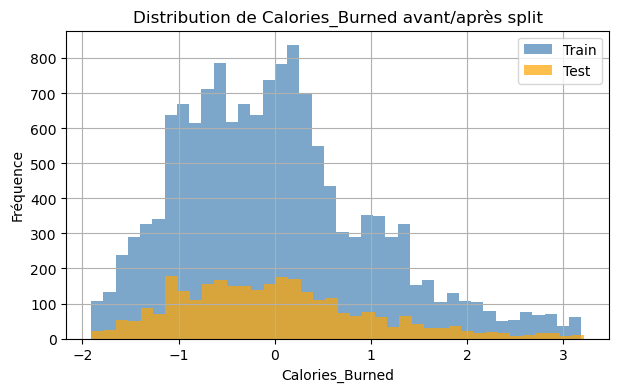

Train mean: 0.00, Test mean: -0.01


In [392]:
plt.figure(figsize=(7,4))
plt.hist(y_train_std, bins=40, alpha=0.7, label="Train", color="steelblue")
plt.hist(y_test_std, bins=40, alpha=0.7, label="Test", color="orange")
plt.legend()
plt.title("Distribution de Calories_Burned avant/après split")
plt.xlabel("Calories_Burned")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

print(f"Train mean: {y_train_std.mean():.2f}, Test mean: {y_test_std.mean():.2f}")

### 8.2. Export des sous-ensembles

Les quatre sous-ensembles sont sauvegardés sous format Parquet, prêts à être utilisés pour l’entraînement et la validation des modèles.

In [393]:
# --- Export des X (déjà DataFrame)
X_train.to_parquet(export_dir / "X_train.parquet", index=False)
X_test.to_parquet(export_dir / "X_test.parquet", index=False)
X_val.to_parquet(export_dir / "X_val.parquet", index=False)

# --- Export des y standardisés (convertir ndarray → Series/DataFrame)
target_col_std = "Calories_Burned_std"

pd.Series(y_train_std, name=target_col_std).to_frame() \
    .to_parquet(export_dir / "y_train.parquet", index=False)

pd.Series(y_test_std, name=target_col_std).to_frame() \
    .to_parquet(export_dir / "y_test.parquet", index=False)

pd.Series(y_val_std, name=target_col_std).to_frame() \
    .to_parquet(export_dir / "y_val.parquet", index=False)

Synthèse & critères d’acceptation :
- La variable cible Calories_Burned est correctement isolée.
- Les proportions de split sont respectées (≈ 80 % / 20 %).
- Les distributions train/test sont similaires → absence de biais de sélection.
- Les fichiers Parquet exportés garantissent la traçabilité et la reproductibilité du pipeline.

Cette étape finalise la préparation des données d’apprentissage, assurant une séparation claire entre entraînement et évaluation.

Elle constitue la base du bloc 5 — Feature Engineering et de l’entraînement des modèles supervisés.

## 9. Sélection ou création de features pertinentes

### 9.1. Objectif

Cette étape vise à optimiser la qualité des variables utilisées pour la modélisation, en éliminant les features redondantes ou peu informatives et en créant de nouvelles variables plus représentatives du phénomène étudié.

Deux approches sont utilisées :
- Sélection de features : identification des variables les plus corrélées à la cible (feature importance).
- Création de nouvelles features : dérivées ou combinaisons logiques des variables existantes (ratios, interactions, indicateurs composites).

In [394]:
X_train = pd.read_parquet(export_dir / "X_train.parquet")
X_test  = pd.read_parquet(export_dir / "X_test.parquet")
y_train = pd.read_parquet(export_dir / "y_train.parquet").squeeze()  # conversion en Series
y_test  = pd.read_parquet(export_dir / "y_test.parquet").squeeze() # conversion en Series


print(f"Données chargées : {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"Données chargées : {X_test.shape[0]} lignes, {X_test.shape[1]} colonnes")

Données chargées : 13992 lignes, 48 colonnes
Données chargées : 2999 lignes, 48 colonnes


### 9.2. Choix des features

#### 9.2.1. Analyse de corrélation et importance des variables

On commence par une analyse de corrélation entre les variables numériques et la cible.

Cette étape permet de repérer les variables les plus influentes sur Calories_Burned.

Une méthode complémentaire basée sur un modèle de RandomForestRegressor est utilisée pour estimer l’importance relative des features.

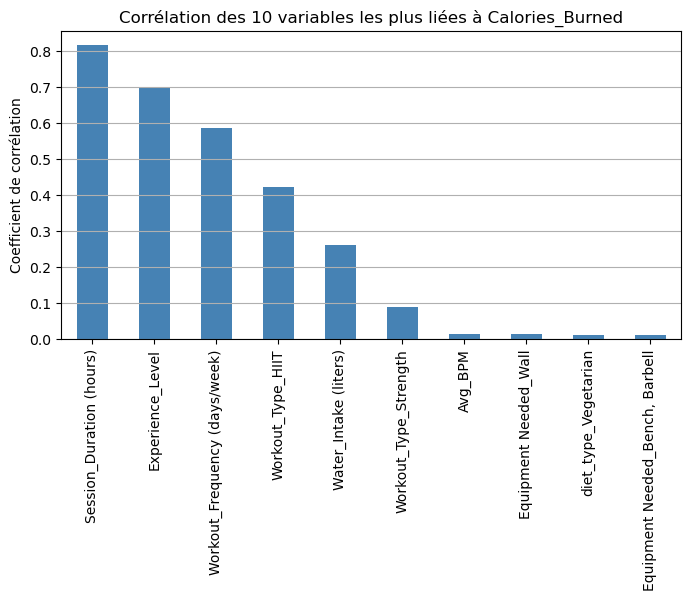


Variables NON présentes dans le TOP 10 corrélation :
 - Equipment Needed_Box or Platform
 - Body Part_Forearms
 - Height (m)
 - Equipment Needed_Bench or Step
 - diet_type_Keto
 - Equipment Needed_None or Dumbbell
 - Equipment Needed_Kettlebell
 - Equipment Needed_Dumbbells
 - Body Part_Legs
 - Body Part_Back
 - meal_type_Lunch
 - Equipment Needed_Dumbbells or Barbell
 - Equipment Needed_Bench or Sturdy Surface
 - meal_type_Dinner
 - Max_BPM
 - Equipment Needed_Cable Machine
 - Equipment Needed_Parallel Bars or Chair
 - Equipment Needed_Pull-up Bar
 - Body Part_Shoulders
 - Difficulty Level
 - Gender_1.0
 - Body Part_Chest
 - Equipment Needed_Step or Box
 - Weight (kg)
 - Equipment Needed_Low Bar or TRX
 - diet_type_Vegan
 - meal_type_Snack
 - diet_type_Paleo
 - diet_type_Low-Carb
 - Equipment Needed_None or Dumbbells
 - Body Part_Arms
 - Equipment Needed_Cable Machine or Resistance Band
 - Resting_BPM
 - Equipment Needed_Resistance Band or Cable Machine
 - Equipment Needed_Resistance

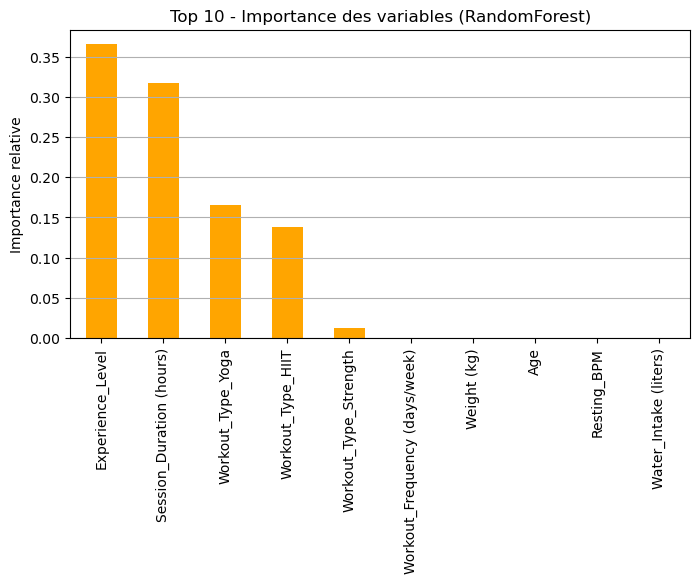


Variables NON présentes dans le TOP 10 importance RF :
 - Fat_Percentage
 - Max_BPM
 - Avg_BPM
 - Height (m)
 - Equipment Needed_Bench or Step
 - Difficulty Level
 - Body Part_Legs
 - Gender_1.0
 - Equipment Needed_Box or Platform
 - Body Part_Forearms
 - Equipment Needed_Step or Box
 - diet_type_Vegan
 - meal_type_Lunch
 - diet_type_Vegetarian
 - meal_type_Snack
 - diet_type_Low-Carb
 - Equipment Needed_Kettlebell
 - meal_type_Dinner
 - Equipment Needed_None or Dumbbell
 - Body Part_Back
 - Body Part_Chest
 - Equipment Needed_Low Bar or TRX
 - diet_type_Paleo
 - Equipment Needed_Resistance Band or Cable Machine
 - Body Part_Shoulders
 - diet_type_Keto
 - Body Part_Arms
 - Equipment Needed_Bench or Sturdy Surface
 - Equipment Needed_Parallel Bars or Chair
 - Equipment Needed_Wall
 - Equipment Needed_Cable Machine
 - Equipment Needed_Pull-up Bar
 - Equipment Needed_Dumbbells
 - Equipment Needed_Dumbbells or Barbell
 - Equipment Needed_Bench, Barbell
 - Equipment Needed_None or Dumbbell

In [395]:
# Calcul des corrélations (variables continues uniquement)
corr = X_train.corrwith(y_train).dropna().sort_values(ascending=False)
top_corr = corr.head(10)

plt.figure(figsize=(8,4))
top_corr.plot(kind="bar", color="steelblue")
plt.title("Corrélation des 10 variables les plus liées à Calories_Burned")
plt.ylabel("Coefficient de corrélation")
plt.grid(True, axis='y')
plt.show()

# Colonnes complètes
all_features = corr.index.tolist()

# Features non utilisées (hors Top 10 corrélation)
excluded_corr = [col for col in all_features if col not in top_corr.index]

print("\nVariables NON présentes dans le TOP 10 corrélation :")
for col in excluded_corr:
    print(" -", col)


# Modèle RandomForest pour importance des features
model_rf = RandomForestRegressor(random_state=42, n_estimators=100)
model_rf.fit(X_train, y_train)

importances = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_importances = importances.head(10)

plt.figure(figsize=(8,4))
top_importances.plot(kind="bar", color="orange")
plt.title("Top 10 - Importance des variables (RandomForest)")
plt.ylabel("Importance relative")
plt.grid(True, axis='y')
plt.show()

# Colonnes complètes
all_features_importances = importances.index.tolist()

# Features non utilisées (hors Top 10 importance RF)
excluded_importances = [col for col in all_features_importances if col not in top_importances.index]

print("\nVariables NON présentes dans le TOP 10 importance RF :")
for col in excluded_importances:
    print(" -", col)

#### 9.2.2. Analyse par corrélation non linéaire (Spearman)

La corrélation de Pearson (celle que tu utilises) ne voit que des relations linéaires.

Spearman détecte les relations monotones non linéaires, souvent mieux adaptées en fitness.

In [396]:
if search_best_features:
    corr_spearman = X_train.corrwith(y_train, method='spearman').dropna().sort_values(ascending=False)

    plt.figure(figsize=(8,4))
    corr_spearman.head(10).plot(kind="bar", color="seagreen")
    plt.title("Corrélation (Spearman) — Top 10")
    plt.ylabel("Coefficient de corrélation")
    plt.grid(True, axis='y')
    plt.show()

#### 9.2.3. Mutual Information (MI)

Méthode incontournable pour vérifier l’importance entre une feature et une target sans hypothèse linéaire, contrairement aux corrélations classiques

In [397]:
if search_best_features:
    mi = mutual_info_regression(X_train, y_train, random_state=42)
    mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

    plt.figure(figsize=(8,4))
    mi_series.head(10).plot(kind='bar', color='purple')
    plt.title("Mutual Information — Top 10")
    plt.ylabel("Score MI")
    plt.grid(axis='y')
    plt.show()

#### 9.2.4. Permutation Importance

Mesure de la perte de performance lorsque l'on “shuffle” une variable.

C’est très fiable, car modèle-indépendant et basé sur l'effet réel dans la prédiction.

In [398]:
if search_best_features:
    perm = permutation_importance(model_rf, X_train, y_train, n_repeats=15, random_state=42)
    perm_series = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)

    plt.figure(figsize=(8,4))
    perm_series.head(10).plot(kind='bar', color='darkred')
    plt.title("Permutation Importance — Top 10")
    plt.ylabel("Importance moyenne")
    plt.grid(axis='y')
    plt.show()

#### 9.2.5. SHAP Values

Parfait pour voir exactement :

- comment chaque variable influence chaque prédiction,
- quelles variables dominent vraiment globalement,
- où se situent les points critiques.

In [399]:
if search_best_features:
    explainer = shap.TreeExplainer(model_rf)
    shap_values = explainer.shap_values(X_train)

    shap.summary_plot(shap_values, X_train)

#### 9.2.6. PDP — Partial Dependence Plots

Idéal pour visualiser l’effet exact d’une variable sur la prédiction, en moyenne.

In [400]:
if search_best_features:
    features_to_check = ["Weight (kg)", "Session_Duration (hours)", "Experience_Level"]

    PartialDependenceDisplay.from_estimator(model_rf, X_train, features_to_check)
    plt.show()

#### 9.2.7. ICE Plots — Individual Conditional Expectation

Similaire au PDP, mais beaucoup plus granulaire :
au lieu d’une moyenne, tu vois l’impact individuel utilisateur par utilisateur.

Super utile si :

- des sous-groupes réagissent différemment,
- la relation moyenne masque des comportements locaux.

In [401]:
if search_best_features:
    PartialDependenceDisplay.from_estimator(model_rf, X_train, ["Session_Duration (hours)"], kind="individual")
    plt.show()

#### 9.2.8. Lasso Regression (pour la sélection par régularisation)

Le Lasso pousse les coefficients non utiles vers 0 → sélection automatique.

In [402]:
if search_best_features:
    lasso = Lasso(alpha=0.001)
    lasso.fit(X_train, y_train)

    coef = pd.Series(lasso.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)

    plt.figure(figsize=(8,4))
    coef.head(30).plot(kind="bar", color="teal")
    plt.title("Importance Lasso (coefficients)")
    plt.grid(True, axis='y')
    plt.show()

### 9.3. Création de nouvelles features

Certaines combinaisons de variables améliorent la capacité prédictive.

On crée ici plusieurs variables dérivées liées à la physiologie et à l’activité physique :
- BPM_effort_ratio = Avg_BPM / Max_BPM
- Fat_to_weight_ratio = Fat_Percentage / Weight (kg)
- Workout_intensity = Calories_Burned / Session_Duration (hours) (proxy de rendement énergétique)
- Hydration_ratio = Water_Intake (liters) / Workout_Frequency (days/week)

In [403]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Ratios cardio
    if {"Avg_BPM", "Max_BPM"}.issubset(df.columns):
        df["BPM_effort_ratio"] = df["Avg_BPM"] / (df["Max_BPM"].replace(0, np.nan))
    # Composition corporelle
    if {"Fat_Percentage", "Weight (kg)"}.issubset(df.columns):
        df["Fat_to_weight_ratio"] = df["Fat_Percentage"] / (df["Weight (kg)"].replace(0, np.nan))
    # Hydratation relative
    if {"Water_Intake (liters)", "Workout_Frequency (days/week)"}.issubset(df.columns):
        df["Hydration_ratio"] = df["Water_Intake (liters)"] / (df["Workout_Frequency (days/week)"] + 1e-3)
    # Nettoyage inf/NaN générés par divisions
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)
    return df

### 9.4. Réduction des features redondantes

Certaines variables peuvent être fortement corrélées entre elles, ce qui nuit à la stabilité du modèle.

On applique un filtrage basé sur la matrice de corrélation et un seuil de tolérance pour supprimer les doublons d’information.

In [404]:
# === Gestion du scaling (REUSE, ne pas refitter) ===
train_features = feature_cols_raw.copy()

# Ajouter les features dérivées si elles existent
extra_feats = ["BPM_effort_ratio", "Fat_to_weight_ratio", "Hydration_ratio"]
extra_feats = [c for c in extra_feats if c in X_train.columns]

for c in extra_feats:
    if c not in train_features:
        train_features.append(c)

print("Features utilisées par le modèle :", train_features)

# Extraction des matrices standardisées
X_train_scaled = X_train[train_features]
X_val_scaled   = X_val[train_features]
X_test_scaled  = X_test[train_features]

# === Analyse de corrélation ===
# Convertir en DataFrame si ce n'est pas déjà le cas
if isinstance(X_train_scaled, np.ndarray):
    X_train_df = pd.DataFrame(X_train_scaled, columns=train_features)
else:
    X_train_df = X_train_scaled.copy()

corr_matrix = X_train_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]

print(f"Variables supprimées pour corrélation élevée (>0.95) : {len(to_drop)}")

X_train_reduced = X_train_df.drop(columns=to_drop, errors="ignore")
X_val_reduced   = X_val_scaled.drop(columns=to_drop, errors="ignore")
X_test_reduced  = X_test_scaled.drop(columns=to_drop, errors="ignore")


Features utilisées par le modèle : ['Age', 'Weight (kg)', 'Height (m)', 'Gender_1.0', 'Experience_Level', 'Difficulty Level', 'Workout_Frequency (days/week)', 'Water_Intake (liters)', 'Fat_Percentage', 'Session_Duration (hours)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga', 'Body Part_Arms', 'Body Part_Back', 'Body Part_Chest', 'Body Part_Forearms', 'Body Part_Legs', 'Body Part_Shoulders', 'Equipment Needed_Bench or Step', 'Equipment Needed_Bench or Sturdy Surface', 'Equipment Needed_Bench, Barbell', 'Equipment Needed_Box or Platform', 'Equipment Needed_Cable Machine', 'Equipment Needed_Cable Machine or Resistance Band', 'Equipment Needed_Dumbbells', 'Equipment Needed_Dumbbells or Barbell', 'Equipment Needed_Kettlebell', 'Equipment Needed_Low Bar or TRX', 'Equipment Needed_None or Dumbbell', 'Equipment Needed_None or Dumbbells', 'Equipment Needed_Parallel Bars or Chair', 'Equipment Needed_Pull-up Bar', 'Equipment Needed_Resista

### 9.5. Export des nouvelles données

On sauvegarde le dataset enrichi et allégé pour les étapes suivantes de modélisation supervisée.

In [405]:
feature_path = export_dir / "X_train_feature_engineered.parquet"
X_train_reduced.to_parquet(feature_path, index=False)

print(f"Export du jeu de données enrichi : {feature_path}")
print(f"Nombre final de colonnes : {X_train_reduced.shape[1]}")

feature_path = export_dir / "X_test_feature_engineered.parquet"
X_test_reduced.to_parquet(feature_path, index=False)

print(f"Export du jeu de données enrichi : {feature_path}")
print(f"Nombre final de colonnes : {X_test_reduced.shape[1]}")

feature_path = export_dir / "X_val_feature_engineered.parquet"
X_val_reduced.to_parquet(feature_path, index=False)

print(f"Export du jeu de données enrichi : {feature_path}")
print(f"Nombre final de colonnes : {X_val_reduced.shape[1]}")

Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_train_feature_engineered.parquet
Nombre final de colonnes : 48
Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_test_feature_engineered.parquet
Nombre final de colonnes : 48
Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_val_feature_engineered.parquet
Nombre final de colonnes : 48


Critères de validation :
- Identification claire des variables les plus influentes sur la cible ;
- Création de nouvelles variables pertinentes et explicables ;
- Suppression des redondances au-delà d’un seuil de corrélation de 0.95 ;
- Aucune valeur manquante introduite lors des transformations.

Cette étape améliore la qualité informationnelle du dataset et prépare le terrain pour la phase 6 – Choix et entraînement du modèle supervisé.

## 10. Choix du modèle d’apprentissage supervisé

### 10.1. Objectif

L’objectif de cette section est de sélectionner et d’entraîner un ou plusieurs modèles supervisés afin de prédire la variable cible Calories_Burned à partir des variables explicatives sélectionnées.

Plusieurs algorithmes seront comparés selon leurs performances et leurs caractéristiques :
- Régression linéaire : modèle de base simple, interprétable et rapide ;
- Random Forest Regressor : modèle non linéaire, robuste et performant sur des données hétérogènes ;
- Gradient Boosting Regressor : modèle plus complexe, souvent plus précis mais plus coûteux en calcul.

In [406]:
X_train = pd.read_parquet(export_dir / "X_train_feature_engineered.parquet")
y_train = pd.read_parquet(export_dir / "y_train.parquet").squeeze()
X_test = pd.read_parquet(export_dir / "X_test_feature_engineered.parquet")
y_test = pd.read_parquet(export_dir / "y_test.parquet").squeeze()
X_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

print(f"Données chargées : {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"Données chargées : {X_test.shape[0]} lignes, {X_test.shape[1]} colonnes")
print(f"Données chargées : {X_val.shape[0]} lignes, {X_val.shape[1]} colonnes")

Données chargées : 13992 lignes, 48 colonnes
Données chargées : 2999 lignes, 48 colonnes
Données chargées : 2999 lignes, 48 colonnes


### 10.2. Modèle de base : Régression linéaire

#### 10.2.1. Base LinearRegression

La régression linéaire sert de point de référence.

Elle permet de mesurer la capacité des features à expliquer la variable cible et sert de baseline pour les modèles plus complexes.

In [407]:
# Baseline linéaire
model_lr = LinearRegression()
model_lr.fit(X_train, y_train_std)
y_pred_lr_std = model_lr.predict(X_val)

mae_lr = mean_absolute_error(y_test, y_pred_lr_std)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr_std))
r2_lr = r2_score(y_test, y_pred_lr_std)

print(f"Régression linéaire → MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R²: {r2_lr:.3f}")

Régression linéaire → MAE: 1.12, RMSE: 1.41, R²: -1.023


#### 10.2.2. Tuning LinearRegression

1. Ridge

Hyperparamètre : alpha
Plus alpha ↑, plus la régularisation L2 est forte.

2. Lasso

Hyperparamètre : alpha
Peut mettre des coefficients exactement à zéro → très utile si tu veux de la sélection de features.

3. ElasticNet

Hyperparamètres : alpha, l1_ratio (entre 0 et 1)
Super utile sur des features corrélées.

In [408]:
if search_best_params:
    print("Comparaison des modèles linéaires (y standardisé)\n")

    # === 1. Baseline : LinearRegression ===
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train_std)
    y_pred_lr = model_lr.predict(X_val)

    mae_lr  = mean_absolute_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    r2_lr   = r2_score(y_test, y_pred_lr)

    print(f"LR (val)       → MAE={mae_lr:.4f}, RMSE={rmse_lr:.4f}, R²={r2_lr:.4f}")

    # === 2. Ridge ===
    param_grid = {"alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 50, 100]}

    ridge = Ridge()
    ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring="r2", n_jobs=-1)
    ridge_cv.fit(X_train, y_train_std)

    best_ridge = ridge_cv.best_estimator_
    y_pred_ridge = best_ridge.predict(X_val)

    mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2_ridge   = r2_score(y_test, y_pred_ridge)

    print(f"Ridge (val)    → MAE={mae_ridge:.4f}, RMSE={rmse_ridge:.4f}, R²={r2_ridge:.4f}")
    print(f"   Best alpha  : {ridge_cv.best_params_['alpha']}")

    # === 3. Lasso ===
    lasso = Lasso(max_iter=20000)
    lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring="r2", n_jobs=-1)
    lasso_cv.fit(X_train, y_train_std)

    best_lasso = lasso_cv.best_estimator_
    y_pred_lasso = best_lasso.predict(X_val)

    mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
    rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    r2_lasso   = r2_score(y_test, y_pred_lasso)

    print(f"Lasso (val)    → MAE={mae_lasso:.4f}, RMSE={rmse_lasso:.4f}, R²={r2_lasso:.4f}")
    print(f"   Best alpha  : {lasso_cv.best_params_['alpha']}")

    # === 4. ElasticNet ===
    param_grid_en = {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    }

    elastic = ElasticNet(max_iter=20000)
    elastic_cv = GridSearchCV(elastic, param_grid_en, cv=5, scoring="r2", n_jobs=-1)
    elastic_cv.fit(X_train, y_train_std)

    best_en = elastic_cv.best_estimator_
    y_pred_en = best_en.predict(X_val)

    mae_en  = mean_absolute_error(y_test, y_pred_en)
    rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
    r2_en   = r2_score(y_test, y_pred_en)

    print(f"ElasticNet (val) → MAE={mae_en:.4f}, RMSE={rmse_en:.4f}, R²={r2_en:.4f}")
    print(f"   Best params   : {elastic_cv.best_params_}")

    # === 5. Tableau récapitulatif ===
    results_lin = pd.DataFrame({
        "Modèle": ["LinearRegression", "Ridge", "Lasso", "ElasticNet"],
        "MAE":    [mae_lr, mae_ridge, mae_lasso, mae_en],
        "RMSE":   [rmse_lr, rmse_ridge, rmse_lasso, rmse_en],
        "R²":     [r2_lr, r2_ridge, r2_lasso, r2_en],
    })

    results_lin = results_lin.sort_values("R²", ascending=False).reset_index(drop=True)
    print("\nRésultats (triés par R² décroissant) :")
    display(results_lin)

    # === 6. Graphe comparatif des R² ===
    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        results_lin["Modèle"], 
        results_lin["R²"], 
        color=plt.cm.tab10.colors  # palette plus lisible
    )

    plt.title("Comparaison des modèles linéaires (R² sur validation)", fontsize=14)
    plt.ylabel("R² (plus haut = meilleur)", fontsize=12)
    plt.xlabel("Modèle", fontsize=12)
    plt.xticks(rotation=25)

    # Grille légère
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # Valeurs affichées au-dessus des barres
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


### 10.3. Modèle non linéaire : Random Forest

#### 10.3.1. Base Random Forest

Le Random Forest Regressor capture les relations non linéaires entre les variables.

Il est moins sensible aux outliers et aux distributions non normales.

In [409]:
model_rf = RandomForestRegressor(random_state=42, n_estimators=200, max_depth=None)
print(X_train.columns)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest → MAE: {mae_rf:.10f}, RMSE: {rmse_rf:.10f}, R²: {r2_rf:.10f}")

Index(['Age', 'Weight (kg)', 'Height (m)', 'Gender_1.0', 'Experience_Level',
       'Difficulty Level', 'Workout_Frequency (days/week)',
       'Water_Intake (liters)', 'Fat_Percentage', 'Session_Duration (hours)',
       'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Workout_Type_HIIT',
       'Workout_Type_Strength', 'Workout_Type_Yoga', 'Body Part_Arms',
       'Body Part_Back', 'Body Part_Chest', 'Body Part_Forearms',
       'Body Part_Legs', 'Body Part_Shoulders',
       'Equipment Needed_Bench or Step',
       'Equipment Needed_Bench or Sturdy Surface',
       'Equipment Needed_Bench, Barbell', 'Equipment Needed_Box or Platform',
       'Equipment Needed_Cable Machine',
       'Equipment Needed_Cable Machine or Resistance Band',
       'Equipment Needed_Dumbbells', 'Equipment Needed_Dumbbells or Barbell',
       'Equipment Needed_Kettlebell', 'Equipment Needed_Low Bar or TRX',
       'Equipment Needed_None or Dumbbell',
       'Equipment Needed_None or Dumbbells',
       'Equipment Needed

#### 10.3.2. Tuning Random Forest

L’intérêt d’une forêt, c’est justement de jouer sur quelques gros hyperparamètres :

- n_estimators : nb d’arbres
- max_depth : profondeur max
- min_samples_split / min_samples_leaf : taille mini des noeuds
- max_features : nb de features considérées à chaque split
- bootstrap / oob_score : échantillonnage avec remise + score OOB

In [410]:
if search_best_params:
    print("Tuning RandomForestRegressor\n")

    # --- Modèle de base (pour comparaison) ---
    base_rf = RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=None
    )
    base_rf.fit(X_train, y_train)
    y_pred_base = base_rf.predict(X_test)

    mae_base = mean_absolute_error(y_test, y_pred_base)
    rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
    r2_base   = r2_score(y_test, y_pred_base)

    print(f"RF baseline → MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")

    # --- Espace de recherche des hyperparamètres ---
    param_dist = {
        "n_estimators": randint(100, 600),
        "max_depth": [None] + list(range(4, 21, 2)),
        "min_samples_split": randint(2, 11),
        "min_samples_leaf": randint(1, 6),
        # plus de "auto" ici, uniquement des valeurs valides
        "max_features": ["sqrt", "log2", None, 0.5],
        "bootstrap": [True, False],
    }


    rf = RandomForestRegressor(random_state=42)

    search_rf = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=N_ITER,
        scoring="r2",
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        # error_score="raise"  # à activer seulement si tu veux déboguer un crash
    )

    search_rf.fit(X_train, y_train)

    print("\nMeilleurs hyperparamètres trouvés :")
    print(search_rf.best_params_)

    best_rf = search_rf.best_estimator_

    # --- Évaluation sur le test ---
    y_pred_best = best_rf.predict(X_test)

    mae_best = mean_absolute_error(y_test, y_pred_best)
    rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
    r2_best   = r2_score(y_test, y_pred_best)

    print("\nPerformance RandomForest optimisée :")
    print(f"RF best     → MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

    print("\nComparatif rapide :")
    print(f"Baseline RF → MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")
    print(f"Best RF     → MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

#### 10.3.3. Sélection du meilleur modèle entre model_rf, base_rf et best_rf

In [411]:
if search_best_params:
    # Règle : on maximise R², puis on minimise MAE, puis RMSE
    candidates = {
        "model_rf": {
            "model": model_rf,
            "mae": mae_rf,
            "rmse": rmse_rf,
            "r2": r2_rf
        }
    }

    # Ajouter la baseline si disponible
    if "base_rf" in locals() and "mae_base" in locals():
        candidates["base_rf"] = {
            "model": base_rf,
            "mae": mae_base,
            "rmse": rmse_base,
            "r2": r2_base
        }

    # Ajouter le best_rf si dispo (search_best_params = True + fit OK)
    if "best_rf" in locals() and "mae_best" in locals():
        candidates["best_rf"] = {
            "model": best_rf,
            "mae": mae_best,
            "rmse": rmse_best,
            "r2": r2_best
        }

    # Sélection du meilleur candidat
    best_key = max(
        candidates.keys(),
        key=lambda k: (candidates[k]["r2"], -candidates[k]["mae"], -candidates[k]["rmse"])
    )

    best_info = candidates[best_key]

    print("\nComparatif des modèles :")
    for name, info in candidates.items():
        print(
            f"- {name:<9} → MAE: {info['mae']:.10f}, "
            f"RMSE: {info['rmse']:.10f}, R²: {info['r2']:.10f}"
        )

    print(f"\nModèle sélectionné : {best_key}")
    print(
        f"   → MAE: {best_info['mae']:.10f}, "
        f"RMSE: {best_info['rmse']:.10f}, R²: {best_info['r2']:.10f}"
    )

    # Variable finale : model_rf
    model_rf = best_info["model"]

### 10.4. Modèle avancé : Bagging Regressor

#### 10.4.1. Base Bagging Regressor

Le Bagging Regressor repose sur le principe du Bootstrap Aggregating. 

Il entraîne en parallèle plusieurs modèles faibles, chacun sur un échantillon tiré avec remise du jeu de données, puis moyenne leurs prédictions.

In [412]:
model_bag = BaggingRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_bag.fit(X_train, y_train)
y_pred_bag = model_bag.predict(X_test)

mae_bag = mean_absolute_error(y_test, y_pred_bag)
rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bag))
r2_bag = r2_score(y_test, y_pred_bag)

print(f"Bagging Regressor → MAE: {mae_bag:.10f}, RMSE: {rmse_bag:.10f}, R²: {r2_bag:.10f}")

Bagging Regressor → MAE: 0.0013022531, RMSE: 0.0030506109, R²: 0.9999905954


#### 10.4.2. Tuning Bagging Regressor

On peut jouer sur :

- n_estimators : nombre d’arbres,
- max_samples : proportion d’échantillons utilisés par arbre,
- max_features : proportion de features utilisées par arbre,
- bootstrap / bootstrap_features : tirage avec ou sans remise.

In [413]:
if search_best_params:
    print("Tuning BaggingRegressor\n")

    # --- Baseline Bagging ---
    base_bag = BaggingRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    base_bag.fit(X_train, y_train)
    y_pred_base = base_bag.predict(X_test)

    mae_base = mean_absolute_error(y_test, y_pred_base)
    rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
    r2_base   = r2_score(y_test, y_pred_base)

    print(f"Bagging baseline → MAE: {mae_base:.4f}, RMSE: {rmse_base:.4f}, R²: {r2_base:.4f}")

    # --- Espace de recherche des hyperparamètres ---
    param_dist_bag = {
        "n_estimators": randint(100, 600),
        "max_samples": uniform(0.5, 0.5),      # entre 0.5 et 1.0
        "max_features": uniform(0.5, 0.5),     # entre 0.5 et 1.0
        "bootstrap": [True, False],
        "bootstrap_features": [False, True],
    }

    bag = BaggingRegressor(
        random_state=42,
        n_jobs=-1
    )

    search_bag = RandomizedSearchCV(
        estimator=bag,
        param_distributions=param_dist_bag,
        n_iter=N_ITER,
        scoring="r2",
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    search_bag.fit(X_train, y_train)

    print("\nMeilleurs hyperparamètres Bagging :")
    print(search_bag.best_params_)

    best_bag = search_bag.best_estimator_

    # --- Évaluation sur le test ---
    y_pred_best = best_bag.predict(X_test)

    mae_best = mean_absolute_error(y_test, y_pred_best)
    rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
    r2_best   = r2_score(y_test, y_pred_best)

    print("\nPerformance Bagging optimisé :")
    print(f"Bagging best     → MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

    print("\nComparatif rapide :")
    print(f"Bagging baseline → MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")
    print(f"Bagging best     → MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

#### 10.4.3. Sélection du meilleur modèle Bagging : model_bag vs base_bag vs best_bag

In [414]:
if search_best_params:
    # Critères : maximiser R², puis minimiser MAE, puis RMSE
    candidates_bag = {
        "model_bag": {
            "model": model_bag,
            "mae": mae_bag,
            "rmse": rmse_bag,
            "r2": r2_bag
        }
    }

    # Ajouter baseline si elle existe
    if "base_bag" in locals() and "mae_base" in locals():
        candidates_bag["base_bag"] = {
            "model": base_bag,
            "mae": mae_base,
            "rmse": rmse_base,
            "r2": r2_base
        }

    # Ajouter best_bag si tuning activé et résultat disponible
    if "best_bag" in locals() and "mae_best" in locals():
        candidates_bag["best_bag"] = {
            "model": best_bag,
            "mae": mae_best,
            "rmse": rmse_best,
            "r2": r2_best
        }

    # Sélection du meilleur modèle
    best_key_bag = max(
        candidates_bag.keys(),
        key=lambda k: (candidates_bag[k]["r2"], -candidates_bag[k]["mae"], -candidates_bag[k]["rmse"])
    )

    best_info_bag = candidates_bag[best_key_bag]

    print("\nComparatif des modèles Bagging :")
    for name, info in candidates_bag.items():
        print(
            f"- {name:<10} → MAE: {info['mae']:.10f}, "
            f"RMSE: {info['rmse']:.10f}, R²: {info['r2']:.10f}"
        )

    print(f"\nModèle Bagging sélectionné : {best_key_bag}")
    print(
        f"   → MAE: {best_info_bag['mae']:.10f}, "
        f"RMSE: {best_info_bag['rmse']:.10f}, R²: {best_info_bag['r2']:.10f}"
    )

    # Variable finale : model_bag
    model_bag = best_info_bag["model"]


### 10.5. Modèle avancé : Gradient Boosting

#### 10.5.1. Base Gradient Boosting

Le Gradient Boosting Regressor ajuste successivement de petits modèles faibles pour corriger les erreurs du précédent.

C’est un excellent compromis entre précision et interprétabilité.

In [415]:
model_gb = GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting → MAE: {mae_gb:.10f}, RMSE: {rmse_gb:.10f}, R²: {r2_gb:.10f}")

Gradient Boosting → MAE: 0.0117179864, RMSE: 0.0155315184, R²: 0.9997562215


#### 10.5.2. Tuning Gradient Boosting

On peut clairement gagner un peu en jouant sur :

- n_estimators
- learning_rate
- max_depth
- min_samples_split, min_samples_leaf
- subsample (stochastic gradient boosting)
- max_features

In [416]:
if search_best_params:
    print("Tuning GradientBoostingRegressor\n")

    # --- Baseline GB (ton modèle actuel) ---
    base_gb = GradientBoostingRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
    )

    base_gb.fit(X_train, y_train)
    y_pred_base = base_gb.predict(X_test)

    mae_base = mean_absolute_error(y_test, y_pred_base)
    rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
    r2_base   = r2_score(y_test, y_pred_base)

    print(f"GB baseline → MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")

    # --- Espace de recherche des hyperparamètres ---
    param_dist_gb = {
        "n_estimators": randint(150, 800),          # nb d'arbres
        "learning_rate": uniform(0.01, 0.19),       # ~ [0.01, 0.20]
        "max_depth": randint(2, 7),                 # profondeur des arbres
        "min_samples_split": randint(2, 11),
        "min_samples_leaf": randint(1, 6),
        "subsample": uniform(0.5, 0.5),             # [0.5, 1.0] → stochastic GB
        "max_features": [None, "sqrt", "log2"],
    }

    gb = GradientBoostingRegressor(random_state=42)

    search_gb = RandomizedSearchCV(
        estimator=gb,
        param_distributions=param_dist_gb,
        n_iter=N_ITER,              
        scoring="r2",
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )

    search_gb.fit(X_train, y_train)

    print("\nMeilleurs hyperparamètres GB :")
    print(search_gb.best_params_)

    best_gb = search_gb.best_estimator_

    # --- Évaluation sur le test ---
    y_pred_best = best_gb.predict(X_test)

    mae_best = mean_absolute_error(y_test, y_pred_best)
    rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
    r2_best   = r2_score(y_test, y_pred_best)

    print("\nPerformance Gradient Boosting optimisé :")
    print(f"GB best      → MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

    print("\nComparatif rapide :")
    print(f"GB baseline  → MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")
    print(f"GB best      → MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

#### 10.5.3. Sélection du meilleur modèle Gradient Boosting : model_gb vs base_gb vs best_gb

In [417]:
if search_best_params:
    # Critères : maximiser R², puis minimiser MAE, puis RMSE
    candidates_gb = {
        "model_gb": {
            "model": model_gb,
            "mae": mae_gb,
            "rmse": rmse_gb,
            "r2": r2_gb
        }
    }

    # Ajouter baseline si elle existe
    if "base_gb" in locals() and "mae_base" in locals():
        candidates_gb["base_gb"] = {
            "model": base_gb,
            "mae": mae_base,
            "rmse": rmse_base,
            "r2": r2_base
        }

    # Ajouter best_gb si tuning activé et résultat disponible
    if "best_gb" in locals() and "mae_best" in locals():
        candidates_gb["best_gb"] = {
            "model": best_gb,
            "mae": mae_best,
            "rmse": rmse_best,
            "r2": r2_best
        }

    # Sélection du meilleur modèle
    best_key_gb = max(
        candidates_gb.keys(),
        key=lambda k: (candidates_gb[k]["r2"], -candidates_gb[k]["mae"], -candidates_gb[k]["rmse"])
    )

    best_info_gb = candidates_gb[best_key_gb]

    print("\nComparatif des modèles Gradient Boosting :")
    for name, info in candidates_gb.items():
        print(
            f"- {name:<10} → MAE: {info['mae']:.10f}, "
            f"RMSE: {info['rmse']:.10f}, R²: {info['r2']:.10f}"
        )

    print(f"\nModèle Gradient Boosting sélectionné : {best_key_gb}")
    print(
        f"   → MAE: {best_info_gb['mae']:.10f}, "
        f"RMSE: {best_info_gb['rmse']:.10f}, R²: {best_info_gb['r2']:.10f}"
    )

    # Variable finale : model_gb
    model_gb = best_info_gb["model"]


### 10.6. Comparaison des modèles

On compare les modèles selon trois métriques principales :
- MAE (Mean Absolute Error) : erreur moyenne absolue ;
- RMSE (Root Mean Squared Error) : pénalise davantage les grosses erreurs ;
- R² : proportion de variance expliquée par le modèle (plus proche de 1 = meilleur).

In [418]:
results = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "Random Forest", "Bagging Regressor", "Gradient Boosting"],
    "MAE": [mae_lr, mae_rf, mae_bag, mae_gb],
    "RMSE": [rmse_lr, rmse_rf, rmse_bag, rmse_gb],
    "R²": [r2_lr, r2_rf, r2_bag, r2_gb]
})

display(results.sort_values("R²", ascending=False).reset_index(drop=True))

,Modèle,MAE,RMSE,R²
0,Bagging Regressor,0.001302,0.003051,0.999991
1,Random Forest,0.001294,0.003055,0.999991
2,Gradient Boosting,0.011718,0.015532,0.999756
3,Régression Linéaire,1.123380,1.414898,-1.023103


### 10.7.  Sélection du meilleur modèle

In [419]:
# Mapping noms → objets modèles
models_dict = {
    "Régression Linéaire": model_lr,
    "Random Forest": model_rf,
    "Bagging Regressor": model_bag,
    "Gradient Boosting": model_gb,
}

# Recherche du nom du meilleur modèle basé sur le R²
best_model_name = results.sort_values("R²", ascending=False).iloc[0]["Modèle"]
best_model = models_dict[best_model_name]

print(f"Meilleur modèle sélectionné : {best_model_name}")
best_model

Meilleur modèle sélectionné : Bagging Regressor


,estimator,None
,n_estimators,200
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


### 10.8. Gestion du scaling

In [420]:
# X_* sont déjà standardisés par le bloc précédent
X_train_scaled = X_train[feature_cols_raw].values
X_val_scaled   = X_val[feature_cols_raw].values
X_test_scaled  = X_test[feature_cols_raw].values

y_train_scaled = y_train_std  # déjà standardisé
y_val_scaled   = y_val_std
y_test_scaled  = y_test_std

### 10.9. Entraînement

In [421]:
# --- Entraînement du modèle sur données normalisées
best_model.fit(X_train_scaled, y_train_scaled)

,estimator,None
,n_estimators,200
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


### 10.10. Vérifier la variance du dataset

In [422]:
# Sanity check variabilité
print("Variance moyenne des features :", np.mean(np.var(X_train_scaled, axis=0)))
print("Variance de la cible :", np.var(y_train_scaled))
y_check = best_model.predict(X_train_scaled[:10])
print("Prédictions sur 10 échantillons :", np.round(y_check, 4))
y_check_kcal = target_scaler.inverse_transform(y_check.reshape(-1, 1)).ravel()
print("Prédictions sur 10 échantillons (kcal) :", np.round(y_check_kcal, 2))

Variance moyenne des features : 1.0
Variance de la cible : 1.0
Prédictions sur 10 échantillons : [-0.2253 -0.792   0.5986  1.1313 -0.102  -0.7241 -0.7775 -0.117   1.0445
  1.1559]
Prédictions sur 10 échantillons (kcal) : [1167.03  883.19 1579.72 1846.55 1228.82  917.19  890.47 1221.32 1803.06
 1858.86]
Prédictions sur 10 échantillons : [-0.2253 -0.792   0.5986  1.1313 -0.102  -0.7241 -0.7775 -0.117   1.0445
  1.1559]
Prédictions sur 10 échantillons (kcal) : [1167.03  883.19 1579.72 1846.55 1228.82  917.19  890.47 1221.32 1803.06
 1858.86]


### 10.11. Vérification des features

In [423]:
feature_names = X_train[best_model.feature_names_in_].columns.tolist() \
    if hasattr(best_model, "feature_names_in_") else X_train.columns.tolist()

setattr(best_model, "feature_names_in_", np.array(feature_names, dtype=object))
print(list(best_model.feature_names_in_))

['Age', 'Weight (kg)', 'Height (m)', 'Gender_1.0', 'Experience_Level', 'Difficulty Level', 'Workout_Frequency (days/week)', 'Water_Intake (liters)', 'Fat_Percentage', 'Session_Duration (hours)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga', 'Body Part_Arms', 'Body Part_Back', 'Body Part_Chest', 'Body Part_Forearms', 'Body Part_Legs', 'Body Part_Shoulders', 'Equipment Needed_Bench or Step', 'Equipment Needed_Bench or Sturdy Surface', 'Equipment Needed_Bench, Barbell', 'Equipment Needed_Box or Platform', 'Equipment Needed_Cable Machine', 'Equipment Needed_Cable Machine or Resistance Band', 'Equipment Needed_Dumbbells', 'Equipment Needed_Dumbbells or Barbell', 'Equipment Needed_Kettlebell', 'Equipment Needed_Low Bar or TRX', 'Equipment Needed_None or Dumbbell', 'Equipment Needed_None or Dumbbells', 'Equipment Needed_Parallel Bars or Chair', 'Equipment Needed_Pull-up Bar', 'Equipment Needed_Resistance Band', 'Equipment Needed_Resist

### 10.12. Sauvegarde des scalers pour être en phase avec "test_model.ipynb" et Gradio

In [424]:
# (optionnel) petite sanity-check sur 10 prédictions test
# On utilise le même espace de features que pour l'entraînement
y_test_pred_std = best_model.predict(X_test_scaled)
y_test_pred_kcal = target_scaler.inverse_transform(y_test_pred_std.reshape(-1, 1)).ravel()
print("Extrait prédictions (kcal):", np.round(y_test_pred_kcal[:10], 2))

c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\.conda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(


Extrait prédictions (kcal): [1689.64 1047.49 1209.2  2201.57  712.44  536.1  1583.31  880.61 1809.92
 1037.94]


### 10.13. Sauvegarde du modèle sélectionné

In [425]:
# Injecter les noms de features (ordre)
setattr(best_model, "feature_names_in_", np.array(feature_names, dtype=object))

# Sauvegarde
joblib.dump(best_model, model_dir / "model.joblib")
print("Modèle et scalers sauvegardés dans :", model_dir)

Modèle et scalers sauvegardés dans : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\models\v1\life_style_data


### 10.14. Validation : chargement et fusion X_val + y_val (en unités réelles)

In [426]:
X_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

df_val = pd.concat([X_val, y_val], axis=1)

### 10.15. Export vers SQLite pour inspection manuelle

In [427]:
con = sqlite3.connect(export_dir / "life_style_data_val.db")
df_val.to_sql("validation_set", con, if_exists="replace", index=False)
con.close()

print(f"Fusion et export terminés : {df_val.shape[0]} lignes, {df_val.shape[1]} colonnes")

Fusion et export terminés : 2999 lignes, 49 colonnes


### 10.16. Informations relatives au choix du modèle (son nom et les métriques associées)

In [428]:
# Détection "friendly" du type de modèle
def model_friendly_name(est):
    if isinstance(est, RandomForestRegressor):
        return "Random Forest"
    if isinstance(est, BaggingRegressor):
        return "Bagging Regressor"
    if isinstance(est, GradientBoostingRegressor):
        return "Gradient Boosting"
    if isinstance(est, LinearRegression):
        return "Régression Linéaire"
    return est.__class__.__name__

# Métriques par modèle (cast en float pour le JSON)
metrics = {
    "Régression Linéaire": {
        "MAE": float(mae_lr), "RMSE": float(rmse_lr), "R2": float(r2_lr)
    },
    "Random Forest": {
        "MAE": float(mae_rf), "RMSE": float(rmse_rf), "R2": float(r2_rf)
    },
    "Bagging Regressor": {
        "MAE": float(mae_bag), "RMSE": float(rmse_bag), "R2": float(r2_bag)
    },
    "Gradient Boosting": {
        "MAE": float(mae_gb), "RMSE": float(rmse_gb), "R2": float(r2_gb)
    }
}

# Infos sur le modèle sélectionné
model_filename = "model.joblib"  # correspond à ton dump: joblib.dump(best_model, model_dir / "model.joblib")
model_path = (model_dir / model_filename).resolve()

best_info = {
    "model_type": model_friendly_name(best_model),
    "model_class": best_model.__class__.__name__,
    "model_path": str(model_path),
    "params": best_model.get_params()
}

# Contexte d’évaluation
report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "target": y.name if hasattr(y, "name") else "Calories_Burned",
    "n_features": int(X_test.shape[1]) if "X_test" in globals() else None,
    "n_test_samples": int(len(y_test)) if "y_test" in globals() else None,
    "metrics_by_model": metrics,
    "selected_model": best_info
}

# Sauvegarde
report_path = model_dir / "model_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"Rapport JSON enregistré : {report_path}")

Rapport JSON enregistré : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\models\v1\life_style_data\model_report.json


### 10.17. Plan de features

In [429]:
# On s'assure que la cible n'est JAMAIS dans selected_features
target_col = "Calories_Burned"
selected_features = [f for f in selected_features if f != target_col]

# Vérification de cohérence
if target_col in selected_features:
    raise ValueError(f"La cible {target_col} ne doit pas figurer dans les features sélectionnées.")
else:
    print(f"Colonne cible '{target_col}' exclue de la liste des features ({len(selected_features)} restantes).")

# Fonction pour inférer le type et les contraintes à partir de X_train (fallback)
def infer_field_spec(name: str, series: pd.Series) -> dict:
    # dtype → type JSON
    if pd.api.types.is_integer_dtype(series):
        ftype = "integer"
    elif pd.api.types.is_float_dtype(series):
        ftype = "number"
    else:
        ftype = "string"

    spec = {"type": ftype}

    if ftype in {"integer", "number"}:
        # bornes observées (n’anéantit pas inference)
        s = series.dropna()
        if not s.empty:
            spec["min_observed"] = float(np.nanmin(s))
            spec["max_observed"] = float(np.nanmax(s))
    else:
        # enum observée (capée à 50 valeurs)
        uniques = series.dropna().astype(str).unique()
        if 0 < len(uniques) <= 50:
            spec["enum_observed"] = sorted(map(str, uniques))

    return spec

# Construire le schéma (priorité aux specs manuelles)
# On part du X_train de l’expérience courante
train_cols = [c for c in selected_features if c in X_train.columns]
schema_features = []

for col in selected_features:
    if col in inference:
        spec = {"name": col, **inference[col], "required": True}
    elif col in train_cols:
        spec = {"name": col, **infer_field_spec(col, X_train[col]), "required": True}
    else:
        # colonne absente du train → type par défaut string
        spec = {"name": col, "type": "string", "required": True}

    schema_features.append(spec)

# Exemple de payload (médiane/mode depuis X_train, sinon placeholders)
example = {}
for f in schema_features:
    name, ftype = f["name"], f["type"]
    if name in X_train.columns:
        s = X_train[name]
        if ftype in {"integer", "number"}:
            val = float(s.median()) if s.notna().any() else (f.get("min") or 0)
            if ftype == "integer":
                val = int(round(val))
            example[name] = val
        else:
            # string
            if "enum" in f:
                example[name] = f["enum"][0]
            elif s.dropna().size > 0:
                example[name] = str(s.dropna().iloc[0])
            else:
                example[name] = ""
    else:
        # fallback si la colonne n’existe pas en train
        if ftype in {"integer", "number"}:
            example[name] = f.get("min", 0)
        else:
            example[name] = f.get("enum", [""])[0] if f.get("enum") else ""

# Objet final du schéma
feature_schema = {
    "model_name": "life_style_data",
    "model_version": MODEL_VERSION,  # ajuste si tu es sur un set élargi
    "created_at": datetime.utcnow().isoformat() + "Z",
    "target": y.name if isinstance(y, pd.Series) else "Calories_Burned",
    "features": schema_features,     # ordre = contrat d’entrée
    "ordering_guarantee": True,      # l’ordre des features est garanti
    "one_hot_handle_unknown": "ignore",  # convention côté pipeline
    "notes": "Schéma d’entrée pour l’inférence REST. Les features dérivées/encodages sont calculées côté backend.",
    "example_payload": example
}

# Sauvegarde
schema_path = model_dir / "feature_schema.json"
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

print(f"Schéma d’entrée sauvegardé : {schema_path.name}")

Colonne cible 'Calories_Burned' exclue de la liste des features (18 restantes).
Schéma d’entrée sauvegardé : feature_schema.json


Critères de validation :
- Modèle entraîné sans erreur ni surapprentissage excessif ;
- Comparaison objective des métriques (MAE, RMSE, R²) ;
- Sauvegarde du meilleur modèle pour l’étape d’optimisation.

Cette section valide le choix du modèle de base et ouvre la voie à la phase 7 — Entraînement, validation et évaluation des performances.

### 10.18. Sélection du meilleur modèle

Le modèle offrant le meilleur R² et la plus faible erreur (MAE/RMSE) est sélectionné pour les étapes suivantes :
- interprétation des résultats,
- optimisation des hyperparamètres (section suivante),
- et déploiement dans le pipeline complet.

## 11. Code complet avec pipeline

In [430]:
# pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler()),
#     ('model', LinearRegression())
# ])

# # 🧱 Pipeline générique
# pipeline = Pipeline(steps=[
#     ("features", FunctionTransformer(create_features, validate=False)),
#     ("scaler", "passthrough"),  # sera remplacé par StandardScaler pour les modèles qui en ont besoin
#     ("model", RandomForestRegressor(random_state=42))  # placeholder
# ])

In [431]:
# # 🔎 Grille de modèles & hyperparamètres
# param_grid = [
#     # A) Random Forest (pas de scaling requis)
#     {
#         "scaler": ["passthrough"],
#         "model": [RandomForestRegressor(random_state=42)],
#         "model__n_estimators": [200, 400],
#         "model__max_depth": [None, 10, 20],
#         "model__min_samples_split": [2, 5]
#     },
#     # B) Gradient Boosting (pas de scaling requis)
#     {
#         "scaler": ["passthrough"],
#         "model": [GradientBoostingRegressor(random_state=42)],
#         "model__n_estimators": [200, 300],
#         "model__learning_rate": [0.05, 0.1],
#         "model__max_depth": [2, 3]
#     },
#     # C) Régression linéaire (scaling nécessaire)
#     {
#         "scaler": [StandardScaler(with_mean=True, with_std=True)],
#         "model": [LinearRegression()]
#         # Pas d'hyperparamètres pour LinearRegression standard
#     }
# ]

# # ⚙️ CV + métriques
# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# grid = GridSearchCV(
#     estimator=pipeline,
#     param_grid=param_grid,
#     scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
#     refit="r2",                # on conserve le meilleur modèle au sens du R²
#     cv= cv,
#     n_jobs=-1,
#     verbose=1
# )

In [432]:
# # pipeline.fit(X_train, y_train)
# grid.fit(X_train, y_train)
# print("Best params:", grid.best_params_)
# print("Best CV R² :", grid.best_score_)

In [433]:
# # y_pred = pipeline.predict(X_test)
# # pd.DataFrame(y_pred,columns=['Predicted_PRICE'])

# best_model = grid.best_estimator_
# # y_pred = best_model.predict(X_test)

# # mae  = mean_absolute_error(y_test, y_pred)
# # rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# # r2   = r2_score(y_test, y_pred)

# # print(f"Test → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

# # 2.2 Appliquer EXACTEMENT les mêmes features aux deux
# df_x = pd.DataFrame(X_val)
# print(df_x)

# y_pred = best_model.predict(X_val)
# # test_pred = best_model.predict(X_test)
# # print(f"Test R²: {r2_score(y_test, test_pred):.3f}")

# mae  = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2   = r2_score(y_test, y_pred)

# print(f"Test → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

# df_val = pd.DataFrame(y_pred)
# df_val
# # df_val = pd.DataFrame(y_pred,columns=['Predicted_PRICE'])
# # y_pred

In [434]:
# # 🧠 Modèle
# model_path = model_dir / "best_pipeline_model.joblib"
# joblib.dump(best_model, model_path)

# # 🧾 Petit rapport
# report = {
#     "best_params": grid.best_params_,
#     "cv_best_r2": float(grid.best_score_),
#     "test_mae": float(mae),
#     "test_rmse": float(rmse),
#     "test_r2": float(r2),
#     "n_features_in": int(X_train.shape[1])
# }
# pd.Series(report).to_json(export_dir / "best_pipeline_model_report.json", indent=2)

# print(f"✔ Modèle sauvegardé → {model_path}")
# print("✔ Rapport → best_supervised_model_report.json")


Conseils d’usage / bonnes pratiques (rapides)
- Zéro fuite de données : le scaler est dans la pipeline, appris uniquement sur le train.
- Même feature engineering partout : FunctionTransformer garantit l’application identique sur train/test.
- Comparaison saine : trois familles de modèles testées, avec une grille raisonnable pour démarrer.
- Prochain step : section “7. Entraînement, validation, évaluation des performances” → on étendra la grille (ou on basculera sur RandomizedSearchCV / Optuna) et on ajoutera des courbes d’apprentissage et permutation importances.

## 12. Conversion df_val to SQLLite


In [435]:
# # Chargement
# X_feature_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
# X_val = pd.read_parquet(export_dir / "X_val.parquet")
# y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

# # Connexion SQLite
# # con = sqlite3.connect(export_dir / "life_style_data_val.db")

# # Fusion sur position (même ordre)
# df_val = pd.concat([X_feature_val, y_val], axis=1)

# # Export
# df_val.to_sql("validation_feature_set", con, if_exists="replace", index=False)


# # Fusion sur position (même ordre)
# df_val = pd.concat([X_val, y_val], axis=1)

# # Export
# df_val.to_sql("validation_set", con, if_exists="replace", index=False)

# con.close()

# print(f"✔ Fusion et export terminés : {df_val.shape[0]} lignes, {df_val.shape[1]} colonnes")


## 13. Nettoyage post-traitement

In [436]:
# Suppression des fichiers parquet générés (X/Y train/val/test + feature_engineered)
files_to_delete = [
    "X_train.parquet",
    "X_train_feature_engineered.parquet",
    "X_val.parquet",
    "X_val_feature_engineered.parquet",
    "X_test.parquet",
    "X_test_feature_engineered.parquet",
    "y_train.parquet",
    "y_val.parquet",
    "y_test.parquet",

    "life_style_data_clean.parquet",
    "life_style_data_encoded.parquet",
    "life_style_data_feature.parquet",
    "life_style_data_scaled.parquet"
]

for p in files_to_delete:
    f = (export_dir / p)
    if f.exists():
        f.unlink()
        print(f"Supprimé : {p}")
    else:
        print(f"⤷ Ignoré (introuvable) : {p}")


Supprimé : X_train.parquet
Supprimé : X_train_feature_engineered.parquet
Supprimé : X_val.parquet
Supprimé : X_val_feature_engineered.parquet
Supprimé : X_test.parquet
Supprimé : X_test_feature_engineered.parquet
Supprimé : y_train.parquet
Supprimé : y_val.parquet
Supprimé : y_test.parquet
Supprimé : life_style_data_clean.parquet
Supprimé : life_style_data_encoded.parquet
Supprimé : life_style_data_feature.parquet
Supprimé : life_style_data_scaled.parquet
